In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [22]:
df=pd.read_csv(r'C:\Users\USER\Documents\Numpy\Country data_AI\Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [24]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [25]:
df.drop_duplicates(inplace=True)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [35]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [45]:
# Define numerical columns
num_cols = ['child_mort', 'exports', 'health', 'imports', 'income', 
            'inflation', 'life_expec', 'total_fer', 'gdpp']

In [53]:
# Set up figure size
plt.figure(figsize=(13, 12))

<Figure size 1300x1200 with 0 Axes>

<Figure size 1300x1200 with 0 Axes>

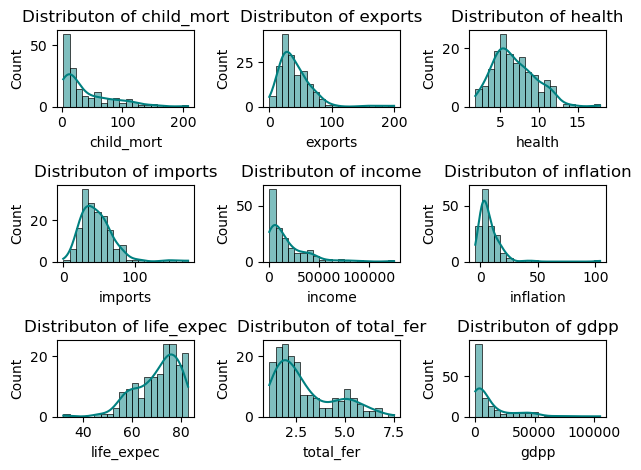

In [71]:
#plot histograms
for i, col in enumerate(num_cols):
    plt.subplot(3,3, i+1)
    sns.histplot(df[col], bins = 20, kde=True, color = 'teal')
    plt.title(f'Distributon of {col}')
plt.tight_layout()
plt.show()

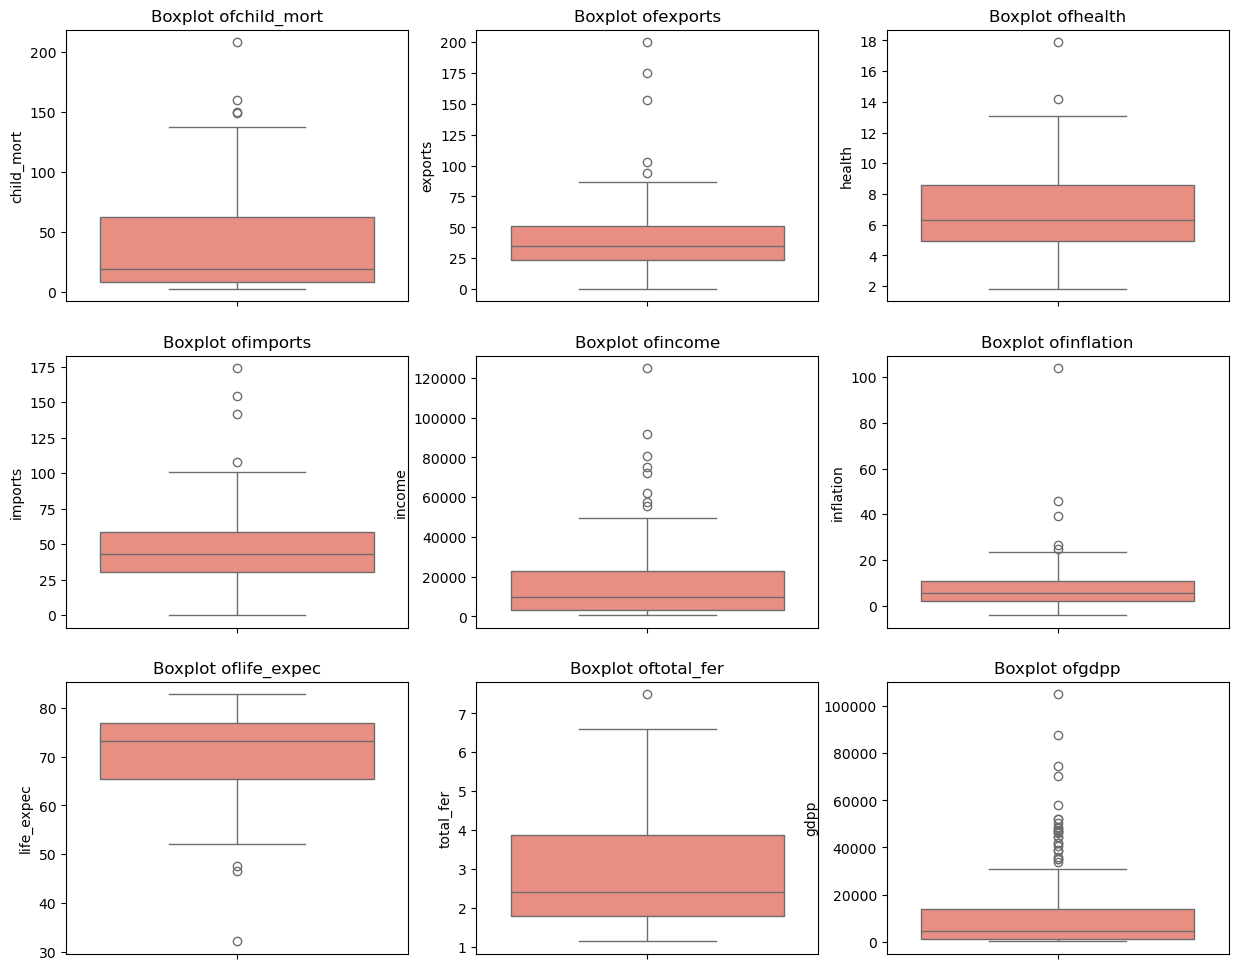

In [85]:
#Boxplot to check outliers
plt.figure(figsize=(15,12))
for i, col in enumerate(num_cols):
    plt.subplot(3,3, i+1)
    sns.boxplot(y=df[col], color ='salmon')
    plt.title(f'Boxplot of{col}')

# plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'GDPP vs Income')

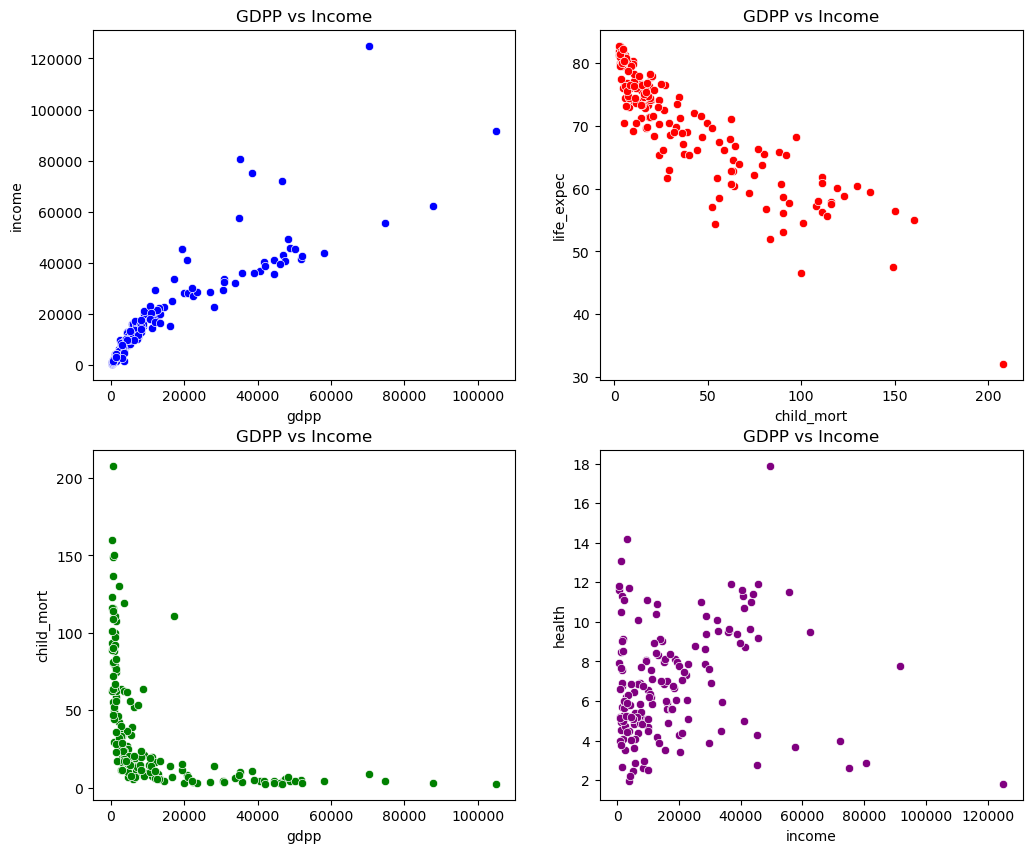

In [97]:
fig, axes = plt.subplots(2,2,figsize=(12,10))

#GDPP vs Income
sns.scatterplot(data=df, x="gdpp", y="income", ax=axes[0, 0], color = "blue")
axes[0,0].set_title("GDPP vs Income")
#Child Mortality vs Life_Expectancy
sns.scatterplot(data=df, x="child_mort", y="life_expec", ax=axes[0, 1], color = "red")
axes[0,1].set_title("GDPP vs Income")
# GDPP vs Child Mortality
sns.scatterplot(data=df, x="gdpp", y="child_mort", ax=axes[1, 0], color = "green")
axes[1,0].set_title("GDPP vs Income")
# Income vs Health Spending
sns.scatterplot(data=df, x="income", y="health", ax=axes[1, 1], color = "purple")
axes[1,1].set_title("GDPP vs Income")

In [95]:
df1 = df.copy()
# Define GDP categories based on percentiles
df1["GDP_Category"] = pd.qcut(df1["gdpp"], q=3, labels=["Low", "Medium", "High"])

C:\Users\USER\AppData\Local\Temp\ipykernel_5288\838277781.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="GDP_Category", y="child_mort", ax=axes[0], palette="coolwarm")
C:\Users\USER\AppData\Local\Temp\ipykernel_5288\838277781.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="GDP_Category", y="life_expec", ax=axes[1], palette="coolwarm")
C:\Users\USER\AppData\Local\Temp\ipykernel_5288\838277781.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="GDP_Category", y="total_fer", ax=axes[2], palette="

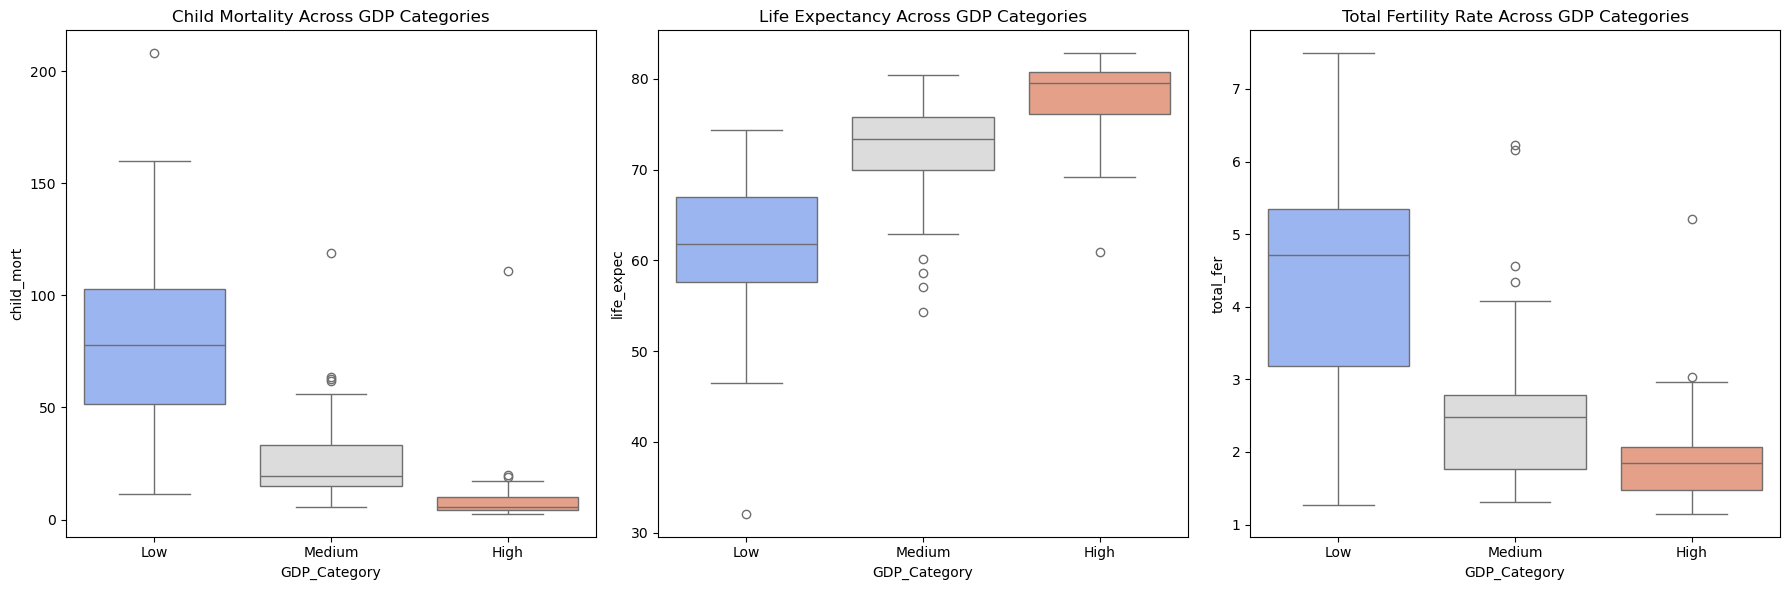

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Child Mortality vs GDP Category
sns.boxplot(data=df1, x="GDP_Category", y="child_mort", ax=axes[0], palette="coolwarm")
axes[0].set_title("Child Mortality Across GDP Categories")

# Life Expectancy vs GDP Category
sns.boxplot(data=df1, x="GDP_Category", y="life_expec", ax=axes[1], palette="coolwarm")
axes[1].set_title("Life Expectancy Across GDP Categories")

# Total Fertility Rate vs GDP Category
sns.boxplot(data=df1, x="GDP_Category", y="total_fer", ax=axes[2], palette="coolwarm")
axes[2].set_title("Total Fertility Rate Across GDP Categories")

plt.tight_layout()
plt.show()

In [101]:
# Selecting only the numerical columns (excluding 'country')
num_cols = df.columns[1:]

# Initializing the scaler
scaler = MinMaxScaler()

# Applying the scaler to numerical columns
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# Display the first few rows of the scaled dataset
df_scaled.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,Albania,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,Algeria,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,Angola,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,Antigua and Barbuda,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


In [105]:
# Define the range of clusters to test
k_values = range(2, 11)

# Lists to store metrics
inertia_values = []
silhouette_scores = []

# Iterate over different cluster sizes
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled.iloc[:, 1:])  # Excluding the 'country' column
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled.iloc[:, 1:], kmeans.labels_))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

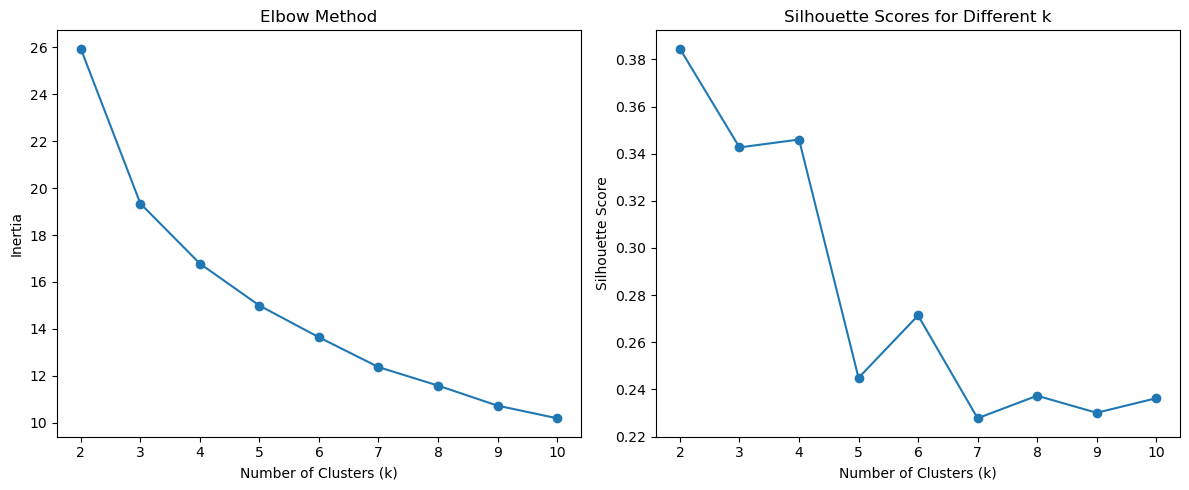

In [115]:
# Plot the Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) #using "mnp" 
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# Plot the Silhouette Scores
plt.subplot(1, 2, 2) #using "mnp" 
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")

plt.tight_layout()
plt.show()

Total variance explained by 2 components: 0.68


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


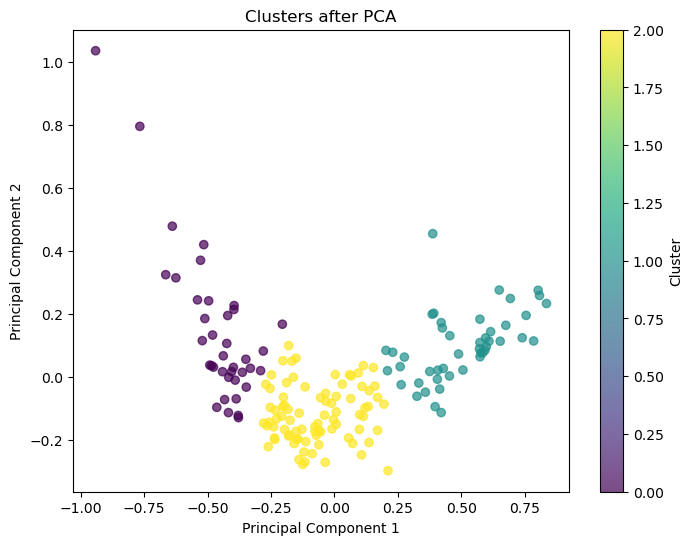

In [117]:
optimal_k = 3

# Apply PCA to reduce dimensions
pca = PCA(n_components=2)  # Reduce to 2D for easy visualization
df_pca = pca.fit_transform(df_scaled.iloc[:, 1:])  # Exclude 'country'

# Explained variance ratio
explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total variance explained by 2 components: {explained_variance:.2f}")

# Convert to DataFrame for clustering
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

# Perform clustering on reduced dimensions
kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_pca.fit_predict(df_pca)  # Store cluster labels separately

# Create a new DataFrame that includes clusters (only for visualization)
df_pca_clusters = df_pca.copy()
df_pca_clusters['Cluster'] = cluster_labels  

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_clusters['PC1'], df_pca_clusters['PC2'], c=df_pca_clusters['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clusters after PCA")
plt.colorbar(label="Cluster")
plt.show()